<a href="https://colab.research.google.com/github/saifulroni/clusters_data/blob/main/clustering_loan_data_Processed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

K-Means Clustering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import MiniBatchKMeans

In [ ]:
url = 'https://raw.githubusercontent.com/muajnstu/Large_Scale_Implementation_of_DSK_Chain/refs/heads/main/Cleaned_Data/loan_data_Processed_.csv'
df = pd.read_csv(url)
df.head()

,person_age,person_gender,person_education,person_income,loan_amnt,loan_int_rate,credit_score,previous_loan_defaults_on_file,loan_status,person_home_ownership_MORTGAGE,person_home_ownership_OWN,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,0,4,71948.0,35000.0,16.02,561,0,1,0,0,0,0,0,0,1,0
1,21.0,0,1,12282.0,1000.0,11.14,504,1,0,0,1,0,1,0,0,0,0
2,25.0,0,1,12438.0,5500.0,12.87,635,0,1,1,0,0,0,0,1,0,0
3,23.0,0,3,79753.0,35000.0,15.23,675,0,1,0,0,0,0,0,1,0,0
4,24.0,1,4,66135.0,35000.0,14.27,586,0,1,0,0,0,0,0,1,0,0


In [ ]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

X_0 = X[y == 0]
X_1 = X[y == 1]

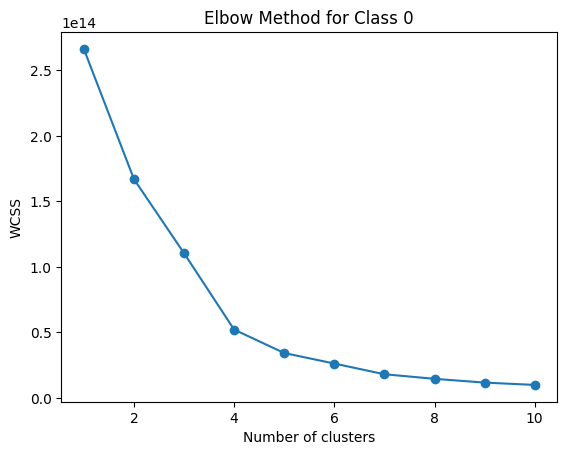

In [ ]:
wcss_0 = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_0)
    wcss_0.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss_0, marker='o')
plt.title('Elbow Method for Class 0')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

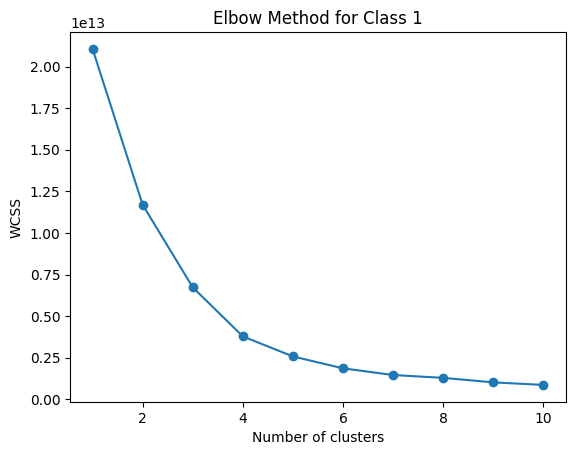

In [ ]:
wcss_1 = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_1)
    wcss_1.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss_1, marker='o')
plt.title('Elbow Method for Class 1')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
n_clusters_0 = 4   # <-- set based on elbow visualization
n_clusters_1 = 3   # <-- set based on elbow visualization

kmeans_0 = KMeans(n_clusters=n_clusters_0, random_state=42)
sub_labels_0 = kmeans_0.fit_predict(X_0)

kmeans_1 = KMeans(n_clusters=n_clusters_1, random_state=42)
sub_labels_1 = kmeans_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 7600 samples
Class 0 - Cluster 1: 6170 samples
Class 0 - Cluster 2: 8510 samples
Class 0 - Cluster 3: 6031 samples
Class 0 - Cluster 4: 6689 samples


In [ ]:
counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 1 - Cluster 0: 2163 samples
Class 1 - Cluster 1: 2378 samples
Class 1 - Cluster 2: 1552 samples
Class 1 - Cluster 3: 1128 samples
Class 1 - Cluster 4: 1258 samples
Class 1 - Cluster 5: 1521 samples


DBSCAN

In [ ]:
dbscan_0 = DBSCAN(eps=0.5, min_samples=5)
sub_labels_0 = dbscan_0.fit_predict(X_0)

dbscan_1 = DBSCAN(eps=0.5, min_samples=5)
sub_labels_1 = dbscan_1.fit_predict(X_1)

In [ ]:
unique_0, counts_0 = np.unique(sub_labels_0, return_counts=True)
for cluster, count in zip(unique_0, counts_0):
    print(f"Class 0 - Cluster {cluster}: {count} samples")

Class 0 - Cluster -1: 35000 samples


In [ ]:
unique_1, counts_1 = np.unique(sub_labels_1, return_counts=True)
for cluster, count in zip(unique_1, counts_1):
    print(f"Class 1 - Cluster {cluster}: {count} samples")

Class 1 - Cluster -1: 10000 samples


Hierarchical Clustering

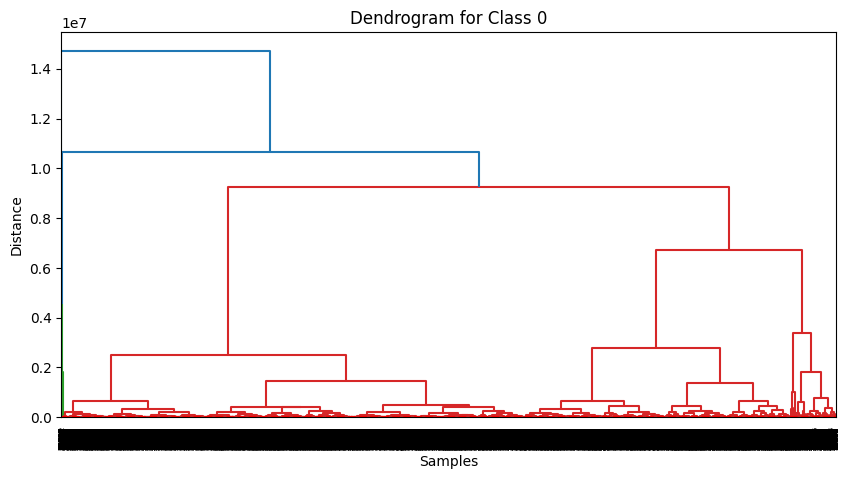

In [ ]:
# Generate linkage matrix for Class 0
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_0, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram for Class 0")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.axhline(y=5, color='r', linestyle='--')
plt.show()

In [ ]:
Z = linkage(X_0, method='ward')

cluster_labels = fcluster(Z, t=10000, criterion='distance')

n_clusters = len(np.unique(cluster_labels))
print(f"Number of clusters: {n_clusters}")

Number of clusters: 763


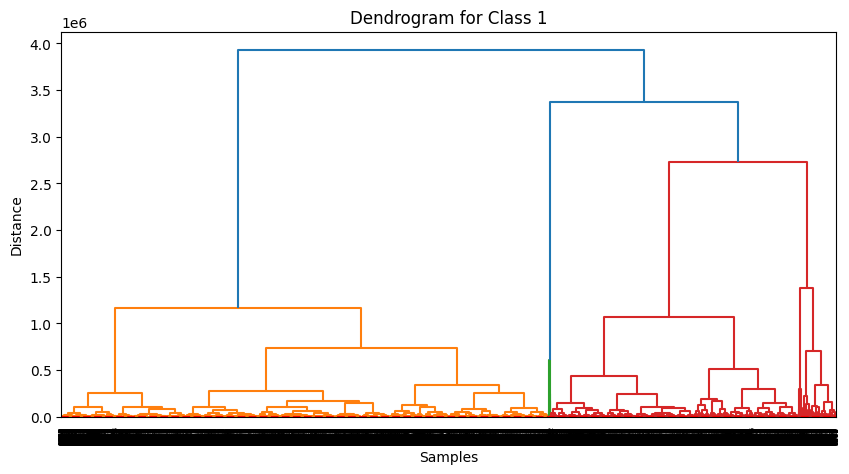

In [ ]:
# Generate linkage matrix for Class 1
Z = linkage(X_1, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram for Class 1")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.axhline(y=5, color='r', linestyle='--')
plt.show()

In [ ]:
Z = linkage(X_1, method='ward')

cluster_labels = fcluster(Z, t=10000, criterion='distance')

n_clusters = len(np.unique(cluster_labels))
print(f"Number of clusters: {n_clusters}")

Number of clusters: 344


second method

In [ ]:
hc_0 = AgglomerativeClustering(n_clusters=2, linkage='ward')
sub_labels_0 = hc_0.fit_predict(X_0)

hc_1 = AgglomerativeClustering(n_clusters=2, linkage='ward')
sub_labels_1 = hc_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 34997 samples
Class 0 - Cluster 1: 3 samples
Class 1 - Cluster 0: 3710 samples
Class 1 - Cluster 1: 6290 samples


Spectral Clustering

1.

In [ ]:
def run_spectral_clustering(X_data, class_label):
    best_score = -1
    best_k = None
    best_labels = None

    # Search for the best number of clusters
    for k in range(2, 7):
        sc = SpectralClustering(
            n_clusters=k,
            affinity='nearest_neighbors',  # or 'rbf'
            assign_labels='kmeans',
            random_state=42
        )
        labels = sc.fit_predict(X_data)
        score = silhouette_score(X_data, labels)
        print(f"Class {class_label} | n_clusters={k}, Silhouette Score={score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    print(f"Best n_clusters for Class {class_label}: {best_k} (Silhouette Score={best_score:.4f})")
    return best_labels, best_k, best_score


In [ ]:
# ---- Run Spectral Clustering with automatic k selection ----
sub_labels_0, best_k_0, best_score_0 = run_spectral_clustering(X_0, class_label=0)
sub_labels_1, best_k_1, best_score_1 = run_spectral_clustering(X_1, class_label=1)

KeyboardInterrupt: 

In [ ]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import numpy as np
import sys

def run_spectral_clustering(X_data, class_label):
    best_score = -1
    best_k = None
    best_labels = None

    # Step 2: Try several cluster counts
    for k in range(2, 7):
        sc = SpectralClustering(
            n_clusters=k,
            affinity='nearest_neighbors',
            n_neighbors=20,
            assign_labels='kmeans',
            random_state=42
        )

        print(f"Running Spectral Clustering for Class {class_label} with k={k}...")
        sys.stdout.flush()

        labels = sc.fit_predict(X_data)
        score = silhouette_score(X_data, labels)

        print(f"Class {class_label} | n_clusters={k}, Silhouette Score={score:.4f}")
        sys.stdout.flush()

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    print(f"\n✅ Best n_clusters for Class {class_label}: {best_k} (Silhouette Score={best_score:.4f})")
    return best_labels, best_k, best_score


# ---- Run Spectral Clustering with automatic k selection ----
sub_labels_0, best_k_0, best_score_0 = run_spectral_clustering(X_0, class_label=0)
sub_labels_1, best_k_1, best_score_1 = run_spectral_clustering(X_1, class_label=1)

# ---- Show cluster counts ----
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Running Spectral Clustering for Class 0 with k=2...


KeyboardInterrupt: 

2.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

def compute_target_sizes(n_samples, k):
    """Compute near-equal cluster sizes"""
    base = n_samples // k
    extras = n_samples % k
    return [base + (1 if i < extras else 0) for i in range(k)]

def rebalance_labels(X, labels, k, max_iters=10):
    """Greedy rebalance to produce more even clusters"""
    labels = labels.copy()
    n_samples = X.shape[0]
    targets = compute_target_sizes(n_samples, k)

    for _ in range(max_iters):
        counts = np.bincount(labels, minlength=k)
        oversized = [i for i in range(k) if counts[i] > targets[i]]
        undersized = [i for i in range(k) if counts[i] < targets[i]]
        if not oversized or not undersized:
            break

        moved_any = False
        for src in oversized:
            src_idx = np.where(labels == src)[0]
            excess = counts[src] - targets[src]
            if excess <= 0:
                continue
            # Move points to nearest undersized cluster
            distances = np.linalg.norm(
                X[src_idx][:, None, :] - X[[np.where(labels == u)[0][0] for u in undersized]][None,:,:],
                axis=2
            )
            best_undersized = np.array(undersized)[np.argmin(distances, axis=1)]
            order = np.argsort(np.min(distances, axis=1))
            to_move = order[:excess]
            for t in to_move:
                idx = src_idx[t]
                dst = best_undersized[t]
                labels[idx] = dst
                moved_any = True
        if not moved_any:
            break

    return labels

def balanced_kmeans_no_scaling(X_data, k, verbose=True):
    """Run KMeans and rebalance without scaling"""
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels_init = km.fit_predict(X_data)
    if verbose:
        print("Initial cluster counts:", np.bincount(labels_init))
    labels_balanced = rebalance_labels(X_data, labels_init, k)
    if verbose:
        print("Balanced cluster counts:", np.bincount(labels_balanced))
    return labels_balanced

# ---------------------------
# Example: recluster each class
# ---------------------------
# For Class 0
sub_labels_0_bal = balanced_kmeans_no_scaling(X[y==0].values, k=2)

# For Class 1
sub_labels_1_bal = balanced_kmeans_no_scaling(X[y==1].values, k=2)

# Map back to original dataframe
original_df = X.copy()
cluster_labels = pd.Series(index=original_df.index, dtype=int)
cluster_labels.loc[y==0] = sub_labels_0_bal
cluster_labels.loc[y==1] = sub_labels_1_bal + sub_labels_0_bal.max() + 1

original_df['Cluster_Label'] = cluster_labels.astype(int)
original_df.to_csv('Clustered_lung_cancer_balanced_no_scaling.csv', index=False)
print("✅ Balanced clusters (no scaling) saved successfully")


NameError: name 'X' is not defined

***3.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ===============================
# STEP 0: Prepare your data
# ===============================
X = X.copy()  # Replace with your DataFrame
y = y.copy()       # 0/1 labels for classes
target_name = 'loan_status'        # adjust if needed

# ===============================
# STEP 1: Scale features
# ===============================
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# ===============================
# STEP 2: Class-wise clustering
# ===============================
def balanced_kmeans(X_data, class_label, k_range=(2,7)):
    """
    KMeans with automatic k selection based on silhouette score.
    Encourages roughly balanced clusters but does not force exact parity.
    """
    best_score = -1
    best_k = None
    best_labels = None

    for k in range(*k_range):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = kmeans.fit_predict(X_data)
        score = silhouette_score(X_data, labels)

        # Compute balance ratio
        counts = np.bincount(labels)
        balance_ratio = min(counts) / max(counts)
        composite_score = score * balance_ratio  # Encourage balanced clusters

        print(f"Class {class_label} | k={k} | Silhouette={score:.4f} | Balance Ratio={balance_ratio:.3f}")

        if composite_score > best_score:
            best_score = composite_score
            best_k = k
            best_labels = labels

    print(f"✅ Best k for Class {class_label}: {best_k} | Composite Score={best_score:.4f}\n")
    return best_labels, best_k

# Separate features by class
X0_scaled = X_scaled[y==0]
X1_scaled = X_scaled[y==1]

# Run clustering for each class
labels_0, k0 = balanced_kmeans(X0_scaled, class_label=0)
labels_1, k1 = balanced_kmeans(X1_scaled, class_label=1)

# ===============================
# STEP 3: Map cluster labels back to original data
# ===============================
final_df = X.copy()

# Offset class 1 clusters so IDs are unique
offset = max(labels_0) + 1
cluster_labels = pd.Series(index=X.index, dtype=int)
cluster_labels.loc[y==0] = labels_0
cluster_labels.loc[y==1] = labels_1 + offset
final_df['Cluster_Label'] = cluster_labels.astype(int)

# ===============================
# STEP 4: Save final clustered data
# ===============================
final_df.to_csv('Clustered_loan_data_Processed.csv', index=False)
print("✅ Clustered data saved successfully as 'Clustered_loan_data_Processed.csv'")

# ===============================
# STEP 5: Optional cluster summary
# ===============================
def show_cluster_counts(labels, class_label):
    counts = np.bincount(labels)
    total = counts.sum()
    print(f"\n=== Cluster Distribution for Class {class_label} ===")
    for i, count in enumerate(counts):
        pct = (count / total) * 100
        print(f"Cluster {i}: {count} samples ({pct:.2f}%)")
    print(f"Total Samples: {total}")
    print(f"Max-Min Difference: {counts.max() - counts.min()}")
    print(f"Balance Ratio (min/max): {counts.min() / counts.max():.3f}\n")

show_cluster_counts(labels_0, 0)
show_cluster_counts(labels_1, 1)

Class 0 | k=2 | Silhouette=0.0836 | Balance Ratio=0.277
Class 0 | k=3 | Silhouette=0.1441 | Balance Ratio=0.271
Class 0 | k=4 | Silhouette=0.1736 | Balance Ratio=0.424
Class 0 | k=5 | Silhouette=0.2181 | Balance Ratio=0.708
Class 0 | k=6 | Silhouette=0.2574 | Balance Ratio=0.465
✅ Best k for Class 0: 5 | Composite Score=0.1545

Class 1 | k=2 | Silhouette=0.1237 | Balance Ratio=0.276
Class 1 | k=3 | Silhouette=0.1746 | Balance Ratio=0.396
Class 1 | k=4 | Silhouette=0.2207 | Balance Ratio=0.299
Class 1 | k=5 | Silhouette=0.2629 | Balance Ratio=0.469
Class 1 | k=6 | Silhouette=0.2990 | Balance Ratio=0.474
✅ Best k for Class 1: 6 | Composite Score=0.1418

✅ Clustered data saved successfully as 'Clustered_loan_data_Processed.csv'

=== Cluster Distribution for Class 0 ===
Cluster 0: 6170 samples (17.63%)
Cluster 1: 6030 samples (17.23%)
Cluster 2: 7599 samples (21.71%)
Cluster 3: 8512 samples (24.32%)
Cluster 4: 6689 samples (19.11%)
Total Samples: 35000
Max-Min Difference: 2482
Balance Rati

4.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_0 = scaler.fit_transform(X_0)
X_1 = scaler.fit_transform(X_1)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

def balanced_kmeans(X_data, class_label, k_range=(2,7)):
    best_score = -1
    best_k = None
    best_labels = None

    for k in range(*k_range):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = kmeans.fit_predict(X_data)
        score = silhouette_score(X_data, labels)

        counts = np.bincount(labels)
        balance_ratio = min(counts) / max(counts)
        composite = score * balance_ratio  # combine both quality and balance

        print(f"Class {class_label} | k={k} | Silhouette={score:.4f} | Balance Ratio={balance_ratio:.3f}")

        if composite > best_score:
            best_score = composite
            best_k = k
            best_labels = labels

    print(f"✅ Best k for Class {class_label}: {best_k} | Composite Score={best_score:.4f}\n")
    return best_labels, best_k

# Run for both classes
sub_labels_0, best_k_0 = balanced_kmeans(X_0, class_label=0)
sub_labels_1, best_k_1 = balanced_kmeans(X_1, class_label=1)


Class 0 | k=2 | Silhouette=0.0778 | Balance Ratio=0.277
Class 0 | k=3 | Silhouette=0.1225 | Balance Ratio=0.291
Class 0 | k=4 | Silhouette=0.1686 | Balance Ratio=0.424
Class 0 | k=5 | Silhouette=0.2136 | Balance Ratio=0.709
Class 0 | k=6 | Silhouette=0.2546 | Balance Ratio=0.465
✅ Best k for Class 0: 5 | Composite Score=0.1513

Class 1 | k=2 | Silhouette=0.0907 | Balance Ratio=0.312
Class 1 | k=3 | Silhouette=0.1398 | Balance Ratio=0.249
Class 1 | k=4 | Silhouette=0.1843 | Balance Ratio=0.260
Class 1 | k=5 | Silhouette=0.2331 | Balance Ratio=0.475
Class 1 | k=6 | Silhouette=0.2796 | Balance Ratio=0.474
✅ Best k for Class 1: 6 | Composite Score=0.1326



In [ ]:
def show_cluster_counts(labels, class_label):
    counts = np.bincount(labels)
    total = counts.sum()
    print(f"\n=== Cluster Distribution for Class {class_label} ===")
    for i, count in enumerate(counts):
        pct = (count / total) * 100
        print(f"Cluster {i}: {count} samples ({pct:.2f}%)")
    print(f"Total Samples: {total}")
    print(f"Max-Min Difference: {counts.max() - counts.min()}")
    print(f"Balance Ratio (min/max): {counts.min() / counts.max():.3f}\n")

show_cluster_counts(sub_labels_0, 0)
show_cluster_counts(sub_labels_1, 1)


=== Cluster Distribution for Class 0 ===
Cluster 0: 7600 samples (21.71%)
Cluster 1: 6170 samples (17.63%)
Cluster 2: 8510 samples (24.31%)
Cluster 3: 6031 samples (17.23%)
Cluster 4: 6689 samples (19.11%)
Total Samples: 35000
Max-Min Difference: 2479
Balance Ratio (min/max): 0.709


=== Cluster Distribution for Class 1 ===
Cluster 0: 2163 samples (21.63%)
Cluster 1: 2378 samples (23.78%)
Cluster 2: 1552 samples (15.52%)
Cluster 3: 1128 samples (11.28%)
Cluster 4: 1258 samples (12.58%)
Cluster 5: 1521 samples (15.21%)
Total Samples: 10000
Max-Min Difference: 1250
Balance Ratio (min/max): 0.474



In [ ]:
# ✅ STEP 1: Create a clean copy of the original (unscaled) data
original_df = X.copy()  # X = your original feature DataFrame (not scaled)
target_name = 'LUNG_CANCER'  # adjust if different

# ✅ STEP 2: Separate original rows for each class
idx0 = y[y == 0].index
idx1 = y[y == 1].index

# ✅ STEP 3: Map the sub-cluster labels back to the original indices
cluster_labels = pd.Series(index=original_df.index, dtype=int)

# Offset ensures class 1 clusters start after class 0 clusters
offset_for_class1 = sub_labels_0.max() + 1
cluster_labels.loc[idx0] = sub_labels_0
cluster_labels.loc[idx1] = sub_labels_1 + offset_for_class1

# ✅ STEP 4: Attach the serial cluster labels to original data
final_df = original_df.copy()
final_df['Cluster_Label'] = cluster_labels.astype(int)

# ✅ STEP 5: (Optional) Drop target column if present
if target_name in final_df.columns:
    final_df = final_df.drop(columns=[target_name])

# Save to CSV
final_df.to_csv('Clustered_lung_cancer_data.csv', index=False)

print("✅ Clustered data saved successfully as 'Clustered_lung_cancer_data.csv'")

✅ Clustered data saved successfully as 'Clustered_lung_cancer_data.csv'


In [ ]:
clustered_df = pd.read_csv('Clustered_lung_cancer_data.csv')
print(clustered_df.head())

   person_age  person_gender  person_education  person_income  loan_amnt  \
0        22.0              0                 4        71948.0    35000.0   
1        21.0              0                 1        12282.0     1000.0   
2        25.0              0                 1        12438.0     5500.0   
3        23.0              0                 3        79753.0    35000.0   
4        24.0              1                 4        66135.0    35000.0   

   loan_int_rate  credit_score  previous_loan_defaults_on_file  \
0          16.02           561                               0   
1          11.14           504                               1   
2          12.87           635                               0   
3          15.23           675                               0   
4          14.27           586                               0   

   person_home_ownership_MORTGAGE  person_home_ownership_OWN  \
0                               0                          0   
1                 

In [ ]:
# Make a copy to avoid modifying the original 'clustered_df' if it's used elsewhere
df_renamed_cluster = clustered_df.copy()

# Rename the 'Cluster_Label' column to 'loan_status'
df_renamed_cluster = df_renamed_cluster.rename(columns={'Cluster_Label': 'loan_status'})

# Save the DataFrame to a new CSV file
df_renamed_cluster.to_csv('Cluster_loan_data_with_loan_status.csv', index=False)

print("✅ 'Cluster_Label' column has been renamed to 'loan_status', and the updated data saved to 'Clustered_loan_data_with_loan_status.csv'.")
print("Here's the head of the DataFrame with the updated column name:")
print(df_renamed_cluster.head())

✅ 'Cluster_Label' column has been renamed to 'loan_status', and the updated data saved to 'Clustered_loan_data_with_loan_status.csv'.
Here's the head of the DataFrame with the updated column name:
   person_age  person_gender  person_education  person_income  loan_amnt  \
0        22.0              0                 4        71948.0    35000.0   
1        21.0              0                 1        12282.0     1000.0   
2        25.0              0                 1        12438.0     5500.0   
3        23.0              0                 3        79753.0    35000.0   
4        24.0              1                 4        66135.0    35000.0   

   loan_int_rate  credit_score  previous_loan_defaults_on_file  \
0          16.02           561                               0   
1          11.14           504                               1   
2          12.87           635                               0   
3          15.23           675                               0   
4          14.27

In [ ]:
# Create a copy to work with, to avoid modifying the original 'df' DataFrame
df_updated_target = df.copy()

# Drop the original 'loan_status' column if it exists in the DataFrame
# This ensures the new 'loan_status' column (from clustering) effectively replaces the old one.
if 'loan_status' in df_updated_target.columns:
    df_updated_target = df_updated_target.drop(columns=['loan_status'])

# Rename the 'Final_Cluster_Label' column to 'loan_status'
df_updated_target = df_updated_target.rename(columns={'Final_Cluster_Label': 'loan_status'})

# Save the DataFrame to a new CSV file
df_updated_target.to_csv('Clustered_loan_data_with_new_loan_status.csv', index=False)

print("✅ 'Final_Cluster_Label' column has been renamed to 'loan_status', and the updated data saved to 'Clustered_loan_data_with_new_loan_status.csv'.")
print("Here's the head of the DataFrame with the updated column name:")
print(df_updated_target.head())

✅ 'Final_Cluster_Label' column has been renamed to 'loan_status', and the updated data saved to 'Clustered_loan_data_with_new_loan_status.csv'.
Here's the head of the DataFrame with the updated column name:
   person_age  person_gender  person_education  person_income  loan_amnt  \
0        22.0              0                 4        71948.0    35000.0   
1        21.0              0                 1        12282.0     1000.0   
2        25.0              0                 1        12438.0     5500.0   
3        23.0              0                 3        79753.0    35000.0   
4        24.0              1                 4        66135.0    35000.0   

   loan_int_rate  credit_score  previous_loan_defaults_on_file  \
0          16.02           561                               0   
1          11.14           504                               1   
2          12.87           635                               0   
3          15.23           675                               0   
4     

MiniBatchKMeans

In [ ]:
n_clusters_0 = 4
mbk_0 = MiniBatchKMeans(
    n_clusters=n_clusters_0,
    random_state=42,
    batch_size=256,
    max_iter=100
)
sub_labels_0 = mbk_0.fit_predict(X_0)

n_clusters_1 = 3
mbk_1 = MiniBatchKMeans(
    n_clusters=n_clusters_1,
    random_state=42,
    batch_size=256,
    max_iter=100
)
sub_labels_1 = mbk_1.fit_predict(X_1)


In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 16879 samples
Class 0 - Cluster 1: 3969 samples
Class 0 - Cluster 2: 1292 samples
Class 0 - Cluster 3: 12860 samples
Class 1 - Cluster 0: 7689 samples
Class 1 - Cluster 1: 91 samples
Class 1 - Cluster 2: 2220 samples


reclustering

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import warnings

# --- Suppress only expected sklearn warnings ---
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.manifold._spectral_embedding")

# ================================================================
# 1️⃣ Run Spectral Clustering with Auto RBF-Fallback
# ================================================================
def run_spectral_clustering(X_data, class_label=None, forced_k=None, k_range=(2, 7)):
    """
    Runs Spectral Clustering over range(k_range), automatically switching to RBF
    if the nearest_neighbors graph is not fully connected.
    Returns: labels, chosen_k, best_score, all_scores_dict
    """
    all_scores = {}
    best_k = None
    best_score = -np.inf
    best_labels = None
    ks = list(range(k_range[0], k_range[1]))

    for k in ks:
        try:
            sc = SpectralClustering(
                n_clusters=k,
                affinity="nearest_neighbors",
                n_neighbors=15,
                assign_labels="kmeans",
                random_state=42
            )
            labels = sc.fit_predict(X_data)
        except Exception as e:
            print(f"[{class_label}] k={k}: Nearest-neighbor graph failed ({e}), switching to RBF affinity...")
            sc = SpectralClustering(
                n_clusters=k,
                affinity="rbf",
                gamma=0.5,
                assign_labels="kmeans",
                random_state=42
            )
            labels = sc.fit_predict(X_data)

        # compute silhouette
        score = silhouette_score(X_data, labels) if len(np.unique(labels)) > 1 else -1
        all_scores[k] = score

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

        print(f"[{class_label}] k={k} -> silhouette={score:.4f}")

    # if forced_k requested
    if forced_k is not None:
        if forced_k not in all_scores:
            raise ValueError(f"forced_k {forced_k} not in tested ks {ks}")
        print(f"[{class_label}] Using forced_k={forced_k} (silhouette={all_scores[forced_k]:.4f})")

        try:
            sc = SpectralClustering(
                n_clusters=forced_k,
                affinity="nearest_neighbors",
                n_neighbors=15,
                assign_labels="kmeans",
                random_state=42
            )
            forced_labels = sc.fit_predict(X_data)
        except Exception:
            sc = SpectralClustering(
                n_clusters=forced_k,
                affinity="rbf",
                gamma=0.5,
                assign_labels="kmeans",
                random_state=42
            )
            forced_labels = sc.fit_predict(X_data)

        return forced_labels, forced_k, all_scores[forced_k], all_scores

    return best_labels, best_k, best_score, all_scores


# ================================================================
# 2️⃣ Cluster Each Class Separately
# ================================================================
def initial_cluster_by_class(X, y, k_range=(2, 7)):
    labels_by_class = {}
    best_k_by_class = {}
    score_by_class = {}
    for cls in np.unique(y):
        X_cls = X[y == cls]
        labels, chosen_k, best_score, _ = run_spectral_clustering(X_cls, class_label=cls, k_range=k_range)
        labels_by_class[cls] = pd.Series(labels, index=X_cls.index)
        best_k_by_class[cls] = chosen_k
        score_by_class[cls] = best_score
    return labels_by_class, best_k_by_class, score_by_class


# ================================================================
# 3️⃣ Count Samples per Cluster
# ================================================================
def get_cluster_counts(labels_by_class):
    counts = {}
    for cls, ser in labels_by_class.items():
        vc = ser.value_counts().sort_index().to_dict()
        counts[cls] = vc
    return counts


# ================================================================
# 4️⃣ Recluster a Specific Subset
# ================================================================
def recluster_subset(X, y, labels_by_class, class_label, cluster_id, forced_k=None, k_range=(2, 7)):
    mask = (y == class_label) & (labels_by_class[class_label] == cluster_id)
    X_subset = X.loc[mask]
    if X_subset.shape[0] < 2:
        raise ValueError("Subset has fewer than 2 samples; cannot recluster.")

    sub_labels, chosen_k, score, _ = run_spectral_clustering(
        X_subset, class_label=f"{class_label}-{cluster_id}", forced_k=forced_k, k_range=k_range
    )
    return pd.Series(sub_labels, index=X_subset.index), chosen_k, score


# ================================================================
# 5️⃣ Combine Final Labels into One Series
# ================================================================
def assemble_final_labels(X, y, labels_by_class, recluster_results=None):
    final_labels = np.full(len(X), -1, dtype=int)
    offset = 0
    mapping = {}

    for cls in sorted(labels_by_class.keys()):
        cls_series = labels_by_class[cls].reindex(X.loc[y == cls].index)
        for orig_cluster in np.unique(cls_series):
            mask_idx = cls_series[cls_series == orig_cluster].index
            if recluster_results and (cls, orig_cluster) in recluster_results:
                sub_ser = recluster_results[(cls, orig_cluster)].reindex(mask_idx)
                unique_sub = np.unique(sub_ser.dropna())
                for sub in unique_sub:
                    sub_idx = mask_idx[sub_ser.loc[mask_idx] == sub]
                    final_labels[sub_idx] = offset
                    mapping[(cls, orig_cluster, sub)] = offset
                    offset += 1
            else:
                final_labels[mask_idx] = offset
                mapping[(cls, orig_cluster, None)] = offset
                offset += 1

    return final_labels, mapping


# ================================================================
# 🧪 Example Usage
# ================================================================
# Suppose you have:
# X_0 = your feature subset for class 0 (numpy array or DataFrame)
# X, y = full dataset and target labels

# Example single-class clustering:
# sub_labels_0, best_k_0, best_score_0, scores_0 = run_spectral_clustering(X_0, class_label=0, forced_k=3)

# To see cluster sample counts:
# counts_0 = np.bincount(sub_labels_0)
# for i, count in enumerate(counts_0):
#     print(f"Class 0 - Cluster {i}: {count} samples")

In [ ]:
sub_labels_0, best_k_0, best_score_0, scores_0 = run_spectral_clustering(X_0, class_label=0, forced_k=3)

[0] k=2 -> silhouette=0.5022
[0] k=3 -> silhouette=0.4646
[0] k=4 -> silhouette=0.4447
[0] k=5 -> silhouette=0.4373
[0] k=6 -> silhouette=0.4200
[0] Using forced_k=3 (silhouette=0.4646)


In [ ]:
sub_labels_1, best_k_1, best_score_1, scores_1 = run_spectral_clustering(X_1, class_label=1, forced_k=2)

[1] k=2 -> silhouette=0.4476
[1] k=3 -> silhouette=0.3636
[1] k=4 -> silhouette=0.4225
[1] k=5 -> silhouette=0.4142
[1] k=6 -> silhouette=0.2985
[1] Using forced_k=2 (silhouette=0.4476)


In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 13545 samples
Class 0 - Cluster 1: 17778 samples
Class 0 - Cluster 2: 3677 samples
Class 1 - Cluster 0: 5069 samples
Class 1 - Cluster 1: 4931 samples


In [ ]:
recluster_results = {}
for cluster_id in np.unique(sub_labels_0):
    print(f"\nRe-clustering Class 0 - Cluster {cluster_id} into 3 sub-clusters")
    # select the subset of Class 0 corresponding to this cluster
    X_sub = X_0[sub_labels_0 == cluster_id]
    sub_sub_labels, k_val, s_val, _ = run_spectral_clustering(X_sub, class_label=f"0-{cluster_id}", forced_k=3)
    # store in recluster_results keyed by original cluster
    recluster_results[(0, cluster_id)] = pd.Series(sub_sub_labels, index=X_sub.index)

# print distribution
for key, ser in recluster_results.items():
    print(f"Class {key[0]} - Original Cluster {key[1]} -> Reclustered counts:")
    print(ser.value_counts().sort_index())

# Assemble final labels for the entire dataset
labels_by_class = {0: pd.Series(sub_labels_0, index=X_0.index),
                   1: pd.Series(sub_labels_1, index=X_1.index)}

final_labels, mapping = assemble_final_labels(X, y, labels_by_class, recluster_results=recluster_results)
df['Final_Cluster_Label'] = final_labels


Re-clustering Class 0 - Cluster 0 into 3 sub-clusters
[0-0] k=2 -> silhouette=0.5264
[0-0] k=3 -> silhouette=0.4092
[0-0] k=4 -> silhouette=0.3522
[0-0] k=5 -> silhouette=0.3190
[0-0] k=6 -> silhouette=0.3264
[0-0] Using forced_k=3 (silhouette=0.4092)

Re-clustering Class 0 - Cluster 1 into 3 sub-clusters
[0-1] k=2 -> silhouette=0.5304
[0-1] k=3 -> silhouette=0.4545
[0-1] k=4 -> silhouette=0.3681
[0-1] k=5 -> silhouette=0.3029
[0-1] k=6 -> silhouette=0.3140
[0-1] Using forced_k=3 (silhouette=0.4545)

Re-clustering Class 0 - Cluster 2 into 3 sub-clusters
[0-2] k=2 -> silhouette=0.6136
[0-2] k=3 -> silhouette=0.3176
[0-2] k=4 -> silhouette=0.3832
[0-2] k=5 -> silhouette=0.2519
[0-2] k=6 -> silhouette=0.2781
[0-2] Using forced_k=3 (silhouette=0.3176)
Class 0 - Original Cluster 0 -> Reclustered counts:
0    7117
1    2291
2    4137
Name: count, dtype: int64
Class 0 - Original Cluster 1 -> Reclustered counts:
0    5883
1    7678
2    4217
Name: count, dtype: int64
Class 0 - Original Cluste

In [ ]:
# Step 5: Check final distribution
print("\nFinal cluster distribution across all classes:")
print(df['Final_Cluster_Label'].value_counts().sort_index())


Final cluster distribution across all classes:
Final_Cluster_Label
0     7117
1     2291
2     4137
3     5883
4     7678
5     4217
6     1828
7     1339
8      510
9     5069
10    4931
Name: count, dtype: int64
